In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("../")

from ease_recommender import *
from npmi_recommender import *

import pickle as p

def create_mat(row, col, bool_to_int=True):
    # bool_to_int won't count duplicates in the same row, creates a different weighting basically
    if bool_to_int:
        data = np.ones_like(row, dtype=bool)
        return csr_matrix((data, (row, col))).astype(np.int64)
    else:
        data = np.ones_like(row, dtype=np.int64)
        return csr_matrix((data, (row, col)))

def check_if_all_terms_in_str(q, terms):
    for term in terms:
        if term not in q:
            return False

    return True

def get_cat2idx(category_type, D):
    if category_type == "track":
        return D["track2idx"]
    elif category_type == "album":
        return D["album2idx"]
    elif category_type == "artist":
        return D["artist2idx"]
    else:
        raise NotImplementedError

def find_match_using_terms(terms, cat2idx):
    matches = []
    for name in cat2idx.keys():
        if check_if_all_terms_in_str(name, terms):
            matches.append(name)

    if len(matches) > 1:
        raise Exception("Multiple matches found, filter down to a single match", matches)

    return matches[0]

print("loading cache data...")
D = p.load(open("cached_data/spotify_preprocessed.p", "rb"))

print("building csr matrices...")

# TODO: finish implementing track and album level recommendations

# track_mat = create_mat(D["playlist_indices"], D["track_indices"])
# album_mat = create_mat(D["playlist_indices"], D["album_indices"])
artist_mat = create_mat(D["playlist_indices"], D["artist_indices"])

print("done")

cat2idx = get_cat2idx("artist", D)
idx2cat = {v:k for k, v in cat2idx.items()}

loading cache data...
building csr matrices...
done


In [2]:
# use two items that you believe are similar to optimize the value of lambda_

a_name = find_match_using_terms(["sgeir", "7xUZ4069zcyBM4Bn10NQ1c"], cat2idx)
# a_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)

a = cat2idx[a_name]
print(f"{a_name=}")
print(f"Num Rows: {artist_mat[:, a].sum()}")

# a = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]

# b = cat2idx[find_match_using_terms(["Fleet Foxes"], cat2idx)]
# b = cat2idx[find_match_using_terms(["Bon Iver", "4LEiUm1SRbFMgfqnQTwUbQ"], cat2idx)]
# b = cat2idx[find_match_using_terms(["SOHN"], cat2idx)]

# b_name = find_match_using_terms(["7fNWySjsDn74LCawyJ27EQ"], cat2idx)
b_name = find_match_using_terms(["Highas"], cat2idx)
b = cat2idx[b_name]
print(f"{b_name=}")
print(f"Num Rows: {artist_mat[:, b].sum()}")

c_name = find_match_using_terms(["Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)"], cat2idx)
c = cat2idx[c_name]
print(f"{c_name=}")
print(f"Num Rows: {artist_mat[:, c].sum()}")

d_name = find_match_using_terms(["Fleet Foxes"], cat2idx)
d = cat2idx[d_name]
print(f"{d_name=}")
print(f"Num Rows: {artist_mat[:, d].sum()}")

e_name = find_match_using_terms(["Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)"], cat2idx)
e = cat2idx[e_name]
print(f"{e_name=}")
print(f"Num Rows: {artist_mat[:, e].sum()}")

f_name = find_match_using_terms(["Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)"], cat2idx)
f = cat2idx[f_name]
print(f"{f_name=}")
print(f"Num Rows: {artist_mat[:, f].sum()}")

a_name='Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)'
Num Rows: 1981
b_name='Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)'
Num Rows: 412
c_name='Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)'
Num Rows: 71
d_name='Fleet Foxes (spotify:artist:4EVpmkEwrLYEg6jIsiPMIb)'
Num Rows: 12615
e_name='Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)'
Num Rows: 32356
f_name='Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)'
Num Rows: 64


In [4]:
artists_of_interest_queries = [
    ["sgeir", "7xUZ4069zcyBM4Bn10NQ1c"],
    ["Highas"], 
    ["Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)"], 
    ["Fleet Foxes"], 
    ["Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)"],
    ["Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)"]
]

artist_names = [find_match_using_terms(q, cat2idx) for q in artists_of_interest_queries]

artists = [cat2idx[n] for n in artist_names]

artist_names

['Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Fleet Foxes (spotify:artist:4EVpmkEwrLYEg6jIsiPMIb)',
 'Bon Iver (spotify:artist:4LEiUm1SRbFMgfqnQTwUbQ)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)']

In [45]:
# using EASE

top_k = 20
lambda_ = 100

similarity_scores = calculate_ease_for_item_cg(artist_mat, b, lambda_)
top_k_matches = [idx2cat[idx] for idx in np.argsort(-similarity_scores)[:top_k].tolist()]

top_k_matches

['Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)',
 'Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)',
 'Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)',
 'Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)',
 'Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)',
 'Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)',
 'Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)',
 'Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)',
 'Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)',
 'Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)',
 'Max Jury (spotify:artist:3MuPVbFDynbq9zRTAqjRxi)',
 'SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)',
 'Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)',
 'Joseph (spotify:artist:5Wfvw7rDz7HA6gE2z6QhqO)',
 'MUNA (spotify:artist:6xdRb2GypJ7DqnWAI2mHGn)',
 'Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)',
 'The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)',
 'Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)',
 'Matrimony (spotify:a

In [70]:
alpha = optimize_alpha_using_a_to_b_matching_npmi(artist_mat, a, b)
scores = npmi_batch_popularity_weighted(artist_mat, a, alpha)

alpha: 0.0
error: 2130.0
alpha: 1.0
error: 481.499999
alpha: 2.6180339999999998
error: 481.999999
alpha: 1.6180339748439998
error: 481.999999
alpha: 0.618034
error: 476.999999
alpha: 0.381966025156
error: 469.381966025156
alpha: 0.23606799039126328
error: 463.2360679903913
alpha: 0.145898044373474
error: 450.1458980443735
alpha: 0.09016995195631564
error: 431.59016995195634
alpha: 0.055728096087369575
error: 405.55572809608736
alpha: 0.03444185813726137
error: 374.53444185813726
alpha: 0.02128623935200419
error: 343.521286239352
alpha: 0.013155619651676559
error: 303.0131556196517
alpha: 0.00813062023580427
error: 254.50813062023582
alpha: 0.0050249997468150565
error: 207.0050249997468
alpha: 0.0031056206935230965
error: 143.00310562069353
alpha: 0.0019193791797008533
error: 86.5019193791797
alpha: 0.001186241591947237
error: 49.001186241591945
alpha: 0.0007331376360375187
error: 20.000733137636036
alpha: 0.0004531039857508118
error: 11.00045310398575
alpha: 0.000223376660283156
error:

In [69]:
alpha = optimize_alpha_using_a_to_b_matching_npmi(artist_mat, b, c)
scores = npmi_batch_popularity_weighted(artist_mat, b, alpha)

alpha: 0.0
error: 384.5
alpha: 1.0
error: 297.999999
alpha: 2.6180339999999998
error: 298.499999
alpha: 1.6180339748439998
error: 298.499999
alpha: 0.618034
error: 295.499999
alpha: 0.381966025156
error: 291.881966025156
alpha: 0.23606799039126328
error: 287.7360679903913
alpha: 0.145898044373474
error: 276.6458980443735
alpha: 0.09016995195631564
error: 265.59016995195634
alpha: 0.055728096087369575
error: 248.05572809608736
alpha: 0.03444185813726137
error: 223.53444185813726
alpha: 0.02128623935200419
error: 193.021286239352
alpha: 0.013155619651676559
error: 159.51315561965168
alpha: 0.00813062023580427
error: 114.5081306202358
alpha: 0.0050249997468150565
error: 72.00502499974681
alpha: 0.0031056206935230965
error: 33.503105620693525
alpha: 0.0019193791797008533
error: 14.0019193791797
alpha: 0.001186241591947237
error: 5.001186241591947
alpha: 0.0007331376360375187
error: 3.0007331376360376
alpha: 0.0006266159563584229
error: 3.0006266159563584
alpha: 0.0006798134040506423
error:

In [39]:
for i in np.argsort(-scores)[:20]:
#     print(scores[i], idx2cat[i])
    print(scores[i], idx2cat[i])

0.3676505042613824 Dustin Tebbutt (spotify:artist:0z9hynUsIjf0ddI4uHqPWX)
0.3488630266679719 SOHN (spotify:artist:6XZYAWJLL8UIbxAqjKj3cg)
0.34806102935625255 Lo-Fang (spotify:artist:5EDkJDlRNcMs3ewliB24QA)
0.3463723379986018 Allman Brown (spotify:artist:239Y6QdFqVFfdsw6moqSEN)
0.34621652354924154 Novo Amor (spotify:artist:0rZp7G3gIH6WkyeXbrZnGi)
0.343681938969136 Ásgeir Trausti (spotify:artist:7fNWySjsDn74LCawyJ27EQ)
0.3419791215865833 Quiet Arrows (spotify:artist:7KRnRH8bRvoX4ebQwHw2EI)
0.3381373299540338 Bear's Den (spotify:artist:0nJaMZM8paoA5HEUTUXPqi)
0.3381307819185113 Liza Anne (spotify:artist:426VSUSxx9puUYFgp7l7EQ)
0.33617938420924764 Ed Tullett (spotify:artist:5VGsR5wapeJIuRPX26IeGn)
0.3349926055742096 PHOX (spotify:artist:3ix4iw2URncSdE7X292bXy)
0.334939334387544 Volcano Choir (spotify:artist:6gAtOqhriLzOzb3Qqmg5kO)
0.33401689116798783 London Grammar (spotify:artist:3Bd1cgCjtCI32PYvDC3ynO)
0.3337432283406715 James Vincent McMorrow (spotify:artist:7FDlvgcodNfC0IBdWevl4u)
0.33

In [72]:
alpha = optimize_alpha_using_a_to_b_matching_npmi(artist_mat, b, c)
scores = npmi_batch_popularity_weighted(artist_mat, b, alpha)

alpha: 0.0
error: 384.5
alpha: 1.0
error: 297.999999
alpha: 2.6180339999999998
error: 298.499999
alpha: 1.6180339748439998
error: 298.499999
alpha: 0.618034
error: 295.499999
alpha: 0.381966025156
error: 291.881966025156
alpha: 0.23606799039126328
error: 287.7360679903913
alpha: 0.145898044373474
error: 276.6458980443735
alpha: 0.09016995195631564
error: 265.59016995195634
alpha: 0.055728096087369575
error: 248.05572809608736
alpha: 0.03444185813726137
error: 223.53444185813726
alpha: 0.02128623935200419
error: 193.021286239352
alpha: 0.013155619651676559
error: 159.51315561965168
alpha: 0.00813062023580427
error: 114.5081306202358
alpha: 0.0050249997468150565
error: 72.00502499974681
alpha: 0.0031056206935230965
error: 33.503105620693525
alpha: 0.0019193791797008533
error: 14.0019193791797
alpha: 0.001186241591947237
error: 5.001186241591947
alpha: 0.0007331376360375187
error: 3.0007331376360376
alpha: 0.0006266159563584229
error: 3.0006266159563584
alpha: 0.0006798134040506423
error:

In [73]:
for i in np.argsort(-scores)[:20]:
#     print(scores[i], idx2cat[i])
    print(scores[i], idx2cat[i])

4.453759148823906 Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)
4.434538998499968 Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
4.300334729536713 Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)
4.232253820265946 Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)
4.2292938748907085 Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)
4.167407498592512 Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)
3.9338697432407135 Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)
3.909826858259426 Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
3.8487279892799635 Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)
3.8416726626031603 Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
3.801429170926395 Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
3.7651058506926853 SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)
3.7204384563844415 Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)
3.6790005111299604 Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)
3.671051416880918 Phori

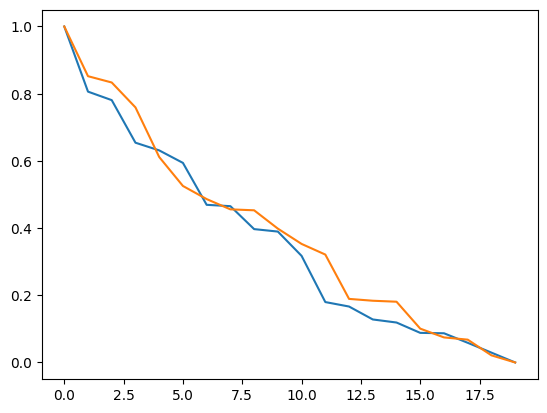

In [22]:
import matplotlib.pyplot as plt

top_k = 20

scores_a = similarity_scores[np.argsort(-similarity_scores)]
scores_a = scores_a[:top_k]
# scores_a = (scores_a - scores_a.mean()) / scores_a.std()
scores_a = (scores_a - scores_a.min()) / (scores_a.max() - scores_a.min())
# scores_a = scores_a / scores_a.max()

scores_b = scores[np.argsort(-scores)]
scores_b = scores_b[:top_k]
# scores_b = (scores_b - scores_b.mean()) / scores_b.std()
scores_b = (scores_b - scores_b.min()) / (scores_b.max() - scores_b.min())
# scores_b = scores_b / scores_b.max()

plt.plot(scores_a);
plt.plot(scores_b);

In [32]:
scores = npmi_batch_popularity_weighted(artist_mat, f, alpha)

for i in np.argsort(-scores)[:top_k]:
    print(idx2cat[i])

Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)
Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)
Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)
Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)
Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)
A-Laget (spotify:artist:2eJz0fbC9ZqBL3mGWPBvI5)
No. 4 (spotify:artist:24YjyPpqFQi1Oh7PQSBT3J)
Carl Louis (spotify:artist:5LY4Rzduoz5b0qZdV3rHwK)
ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)
Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)
Kid Astray (spotify:artist:5fUbM1zPxRNlooyLpOB2j3)
Hkeem (spotify:artist:46XcyK8FnyCJJlvYCUwVZH)
RY X (spotify:artist:2KjAo6wVc9d2WcxdxSArpV)
Adna (spotify:artist:1pduOlnYE5rd4VChXbeU8g)
Gordi (spotify:artist:6UBMFaCTZnL1Hr1nTOEblM)
Ben Cocks feat. Nikisha Reyes-Pile (spotify:artist:0YvRSxCBUYzOSgZaRB3eMb)
Turbonegro (spotify:artist:191rVxQbbZ05wcICUSvLkz)
Arthur Beatrice (spotify:a

In [3]:
# mat = artist_mat
# mat = csr_array(mat)
# # mat = mat.tocoo()

# subset = artists

# # mat_subset = mat[:, subset]
# # valid = mat_subset.sum(axis=1) > 0
# # mat_subset = mat_subset[valid]

# mat_subset = mat

# mat_subset.shape[0]

# n_users, n_items = mat_subset.shape

# X = mat_subset.T @ mat_subset

# X.shape

In [29]:
import numpy as np
from scipy import sparse

def sparse_laplace_sppmi(X, alpha=1.0, normalize=False, zero_diag=True, non_neg=False):
    # Ensure input is CSR for fast row operations
    if not sparse.isspmatrix_csr(X):
        X = X.tocsr()
        
    # 1. Get Geometry of the Data
    # V: Vocabulary size (rows/cols)
    rows, cols = X.shape
    
    # N_raw: Total real observations
    N_raw = X.sum()
    
    # 2. Calculate "Smoothed" Marginals (The Global Statistics)
    # We pretend we added alpha to every cell, but we compute the sums analytically.
    
    # Virtual Total N = Real N + (alpha * Total Possible Cells)
    N_smoothed = N_raw + (alpha * rows * cols)
    
    # Raw marginals (sum of rows/cols)
    row_sums_raw = np.array(X.sum(axis=1)).flatten()
    col_sums_raw = np.array(X.sum(axis=0)).flatten()
    
    # Smoothed marginals = Raw Sum + (alpha * row_length)
    # Each row has 'cols' number of cells, so we add alpha * cols to the row sum
    P_x = (row_sums_raw + (alpha * cols)) / N_smoothed
    P_y = (col_sums_raw + (alpha * rows)) / N_smoothed
    
    # 3. Operate ONLY on Non-Zero Data (The Sparse Trick)
    # We extract the indices of existing data points to calculate their new PMI
    # efficiently, skipping the billions of zeros.
    
    # Create a copy to store results
    sppmi = X.copy().astype(np.float32)
    
    # Get indices of non-zero elements
    row_indices, col_indices = X.tocoo().nonzero()
    
    # Get the raw counts
    raw_counts = np.array(X.data)
    
    # Smooth the counts: Count_new = Count_raw + alpha
    smoothed_counts = raw_counts + alpha
    
    # Calculate P(x,y) for these specific entries
    P_xy = smoothed_counts / N_smoothed
    
    # 4. Vectorized PMI Calculation
    # PMI = log( P(x,y) / (P(x) * P(y)) )
    # Note: P_x[row_indices] grabs the specific P(x) for every non-zero entry
    
    # Numerator is P_xy
    # Denominator is P(x) * P(y)
    denominator = P_x[row_indices] * P_y[col_indices]
    
    # Calculate PMI (using log2)
    pmi_values = np.log2(P_xy / denominator)
    
    if normalize:
        pmi_values = pmi_values / -np.log2(P_xy)
    
    # 7. Update the matrix data
    sppmi.data = pmi_values
    
    if non_neg:
        sppmi.data = np.where(sppmi.data > 0, sppmi.data, 0)
    
    if zero_diag:
        sppmi.setdiag(np.zeros(sppmi.shape[0]))
    
    # 8. Clean up (Remove explicit zeros to keep matrix sparse)
    sppmi.eliminate_zeros()
    
    return sppmi

In [30]:
pmi = sparse_laplace_sppmi(X, alpha=0.085, zero_diag=False)

In [38]:
scores = pmi[b].toarray()

for i in np.argsort(-scores)[:20]:
    print(scores[i], idx2cat[i])

10.40859165651558 Highasakite (spotify:artist:5awQWdBpLqN2KFVRN8w56T)
5.970563799185629 Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
5.922835187138466 Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)
5.758575705105936 Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)
5.754178238553285 Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)
5.614575277783818 Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)
5.582176143625051 Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)
5.363214377830887 Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
5.272243039172707 Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)
5.212601471869403 Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)
5.15147708284573 Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
5.138131422589126 Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)
5.123760785279847 ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)
5.0703906271326336 Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
5.057074381950581 The Whi

In [123]:
# lambda_ = optimize_lambda_using_a_to_b_matching(artist_mat, b, c, fast_approximation=True)

In [11]:
import matplotlib.pyplot as plt

scores_a = similarity_scores[np.argsort(-similarity_scores)]
scores_a = scores_a[1:20]
# scores_a = (scores_a - scores_a.mean()) / scores_a.std()
scores_a = (scores_a - scores_a.min()) / (scores_a.max() - scores_a.min())
# scores_a = scores_a / scores_a.max()

scores_b = scores[np.argsort(-scores)]
scores_b = scores_b[1:20]
# scores_b = (scores_b - scores_b.mean()) / scores_b.std()
scores_b = (scores_b - scores_b.min()) / (scores_b.max() - scores_b.min())
# scores_b = scores_b / scores_b.max()

plt.plot(scores_a);
plt.plot(scores_b);

In [120]:
for i in np.argsort(-scores)[:20]:
#     print(scores[i], idx2cat[i])
    print(idx2cat[i])

Elsa & Emilie (spotify:artist:4HDNQLqhooVfWXtIRMyqMY)
Gabrielle (spotify:artist:4OovmAu23KrDlDQI2UbneL)
Susanne Sundfør (spotify:artist:54KCNI7URCrG6yjQK3Ukow)
Nils Bech (spotify:artist:57QhXfAsLsIRtgC1VfHu1F)
Rockettothesky (spotify:artist:0nu7qEOc8X8UFK10d8lsLw)
Ings (spotify:artist:3wJ2NeHF58Im2tojNX8ESR)
Alice Boman (spotify:artist:3WiytRnvoL0kT3oAGl9TCt)
Ásgeir (spotify:artist:7xUZ4069zcyBM4Bn10NQ1c)
Amason (spotify:artist:4cJKxS7uOPhwb5UQ70sYpN)
Kjartan Lauritzen (spotify:artist:0TW5M8RYADmgeCP1q523hf)
Majical Cloudz (spotify:artist:4BEYBN6NCPrFk3sOLMTby3)
SOAK (spotify:artist:4PLsMEk2DCRVlVL2a9aZAv)
Karpe Diem (spotify:artist:3X23gpg1vPacr0hBARyxtN)
Rubblebucket (spotify:artist:6xriZDSK3wPXhOoZXr9fzF)
Phoria (spotify:artist:0HDxlFsXwyrpufs4YgTNMm)
Matrimony (spotify:artist:4V5UtbLYaFishr7psURF3Q)
Hanzee (spotify:artist:5yM1po4NHvE2yE1Kf84LWJ)
ZL-Project (spotify:artist:4w8PGLhS3yzYSzeV3x2hkA)
The Dø (spotify:artist:2mcNCn1qbZUQ3J9KHapUxj)
Manchester Orchestra, Frightened Rabbit 

In [51]:
x = X.todense()
x

array([[ 1981,    32,     0,   232,   519,     2],
       [   32,   412,    10,    35,    79,    10],
       [    0,    10,    71,     1,     2,     6],
       [  232,    35,     1, 12615,  4708,     3],
       [  519,    79,     2,  4708, 32356,    11],
       [    2,    10,     6,     3,    11,    64]])

In [61]:
pxy = x / n_users

In [63]:
px = np.diagonal(x) / n_users

In [68]:
pmi = np.log2(pxy / (px[:, None] * px[None, :]))

C:\Users\johns\AppData\Local\Temp\ipykernel_11084\4066823951.py:1: RuntimeWarning: divide by zero encountered in log2
  pmi = np.log2(pxy / (px[:, None] * px[None, :]))


In [69]:
pmi

array([[ 4.40619159,  0.71969106,        -inf, -1.35868   , -1.55596333,
        -0.59380841],
       [ 0.71969106,  6.67170423,  3.8438852 , -1.82186534, -2.00626067,
         3.99363232],
       [       -inf,  3.8438852 ,  9.20845763, -4.41439495, -4.77328801,
         5.79342013],
       [-1.35868   , -1.82186534, -4.41439495,  1.73535217, -1.04549487,
        -2.67968533],
       [-1.55596333, -2.00626067, -4.77328801, -1.04549487,  0.37645911,
        -2.16410927],
       [-0.59380841,  3.99363232,  5.79342013, -2.67968533, -2.16410927,
         9.35820475]])

In [71]:
npmi = pmi / -np.log2(pxy)

C:\Users\johns\AppData\Local\Temp\ipykernel_11084\2332673610.py:1: RuntimeWarning: divide by zero encountered in log2
  npmi = pmi / -np.log2(pxy)
C:\Users\johns\AppData\Local\Temp\ipykernel_11084\2332673610.py:1: RuntimeWarning: invalid value encountered in divide
  npmi = pmi / -np.log2(pxy)


In [73]:
npmi
npmi[~np.isfinite(npmi)] = -1

In [79]:
npmi.round(2)

array([[ 1.  ,  0.07, -1.  , -0.18, -0.25, -0.04],
       [ 0.07,  1.  ,  0.32, -0.18, -0.22,  0.33],
       [-1.  ,  0.32,  1.  , -0.29, -0.33,  0.45],
       [-0.18, -0.18, -0.29,  1.  , -0.33, -0.19],
       [-0.25, -0.22, -0.33, -0.33,  1.  , -0.18],
       [-0.04,  0.33,  0.45, -0.19, -0.18,  1.  ]])

In [82]:
pmi.round(2)

array([[ 4.41,  0.72,  -inf, -1.36, -1.56, -0.59],
       [ 0.72,  6.67,  3.84, -1.82, -2.01,  3.99],
       [ -inf,  3.84,  9.21, -4.41, -4.77,  5.79],
       [-1.36, -1.82, -4.41,  1.74, -1.05, -2.68],
       [-1.56, -2.01, -4.77, -1.05,  0.38, -2.16],
       [-0.59,  3.99,  5.79, -2.68, -2.16,  9.36]])

In [100]:
(2**pmi).round(0)

array([[ 21.,   2.,   0.,   0.,   0.,   1.],
       [  2., 102.,  14.,   0.,   0.,  16.],
       [  0.,  14., 592.,   0.,   0.,  55.],
       [  0.,   0.,   0.,   3.,   0.,   0.],
       [  0.,   0.,   0.,   0.,   1.,   0.],
       [  1.,  16.,  55.,   0.,   0., 656.]])